<a href="https://colab.research.google.com/github/jorgevillegazz/Challange-Telecom-X-2/blob/main/Telecom_X_2_delGEORGE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extracción del Archivo Tratado

In [11]:
import pandas as pd

In [21]:
datos = pd.read_csv('/content/datos_tratados.csv')

In [24]:
datos.head()

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


#Eliminación de Columnas Irrelevantes

In [25]:
datos.columns

Index(['Churn', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'ChargesDaily', 'ChargesMonthly', 'ChargesTotal'],
      dtype='object')

In [29]:
cols_eliminar = ['CustomerID', 'daily_charges']
datos = datos.drop(columns=[c for c in cols_eliminar if c in datos.columns])


In [31]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7043 non-null   object 
 1   Gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   Tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [36]:
cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in cols_to_fix:
    datos[col] = datos[col].replace({'No internet service': 'No'})


In [33]:
categoricas = datos.select_dtypes(include='object').columns.tolist()
print(f"\nColumnas categóricas a codificar ({len(categoricas)}):")
print(categoricas)

datos_modelo = pd.get_dummies(datos, columns=categoricas, drop_first=True)
print(f"\nForma tras codificación: {datos_modelo.shape}")
datos_modelo.head()


Columnas categóricas a codificar (17):
['Churn', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Forma tras codificación: (7043, 25)


,Tenure,ChargesDaily,ChargesMonthly,ChargesTotal,Churn_Yes,Gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,9,2.19,65.6,593.30,False,False,False,True,True,True,...,False,True,True,False,True,False,True,False,False,True
1,9,2.00,59.9,542.40,False,True,False,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,4,2.46,73.9,280.85,True,True,False,False,False,True,...,True,False,False,False,False,False,True,False,True,False
3,13,3.27,98.0,1237.85,True,True,True,True,False,True,...,True,False,True,True,False,False,True,False,True,False
4,3,2.80,83.9,267.40,True,False,True,True,False,True,...,False,True,True,False,False,False,True,False,False,True


#Correlación entre variables numericas

In [41]:

import seaborn as sns


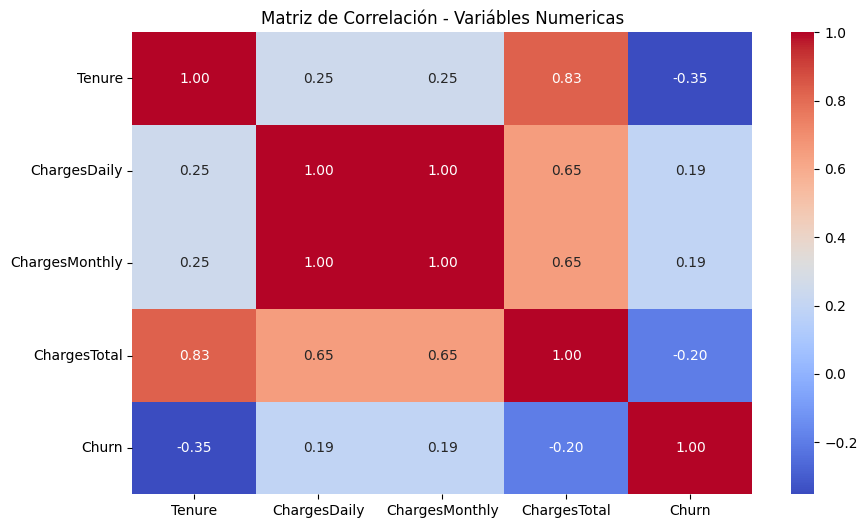

In [42]:
datos_numeric = datos.select_dtypes(include=["int64", "float64"])

datos_numeric["Churn"] = datos["Churn"].map({"Yes": 1, "No": 0})

corr_matrix = datos_numeric.corr()

# Visualizar heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variábles Numericas")
plt.show()


In [43]:
datos = datos.drop(columns=["ChargesDaily","ChargesTotal"])

#Analisis de churn por categoria (variables categoricas)

##Seleccionar variables categoricas

In [44]:
categorical_cols = datos.select_dtypes(include=["object"]).columns
categorical_cols = categorical_cols.drop("Churn")




##Tabla de proporción por categoria

In [45]:
for col in categorical_cols:
    print(f"\n📌 Analisis de variable: {col}")
    display(pd.crosstab(datos[col], datos["Churn"], normalize="index") * 100)



📌 Analisis de variable: Gender


Churn,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338



📌 Analisis de variable: SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261



📌 Analisis de variable: Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858



📌 Analisis de variable: PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092



📌 Analisis de variable: PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


#Metodo recomendado: Qui-cuadrado (Chi-Square Test)

In [46]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

# Crea copia
datos_rank = datos.copy()

# Convertir Churn para binario
datos_rank["Churn"] = datos_rank["Churn"].map({"Yes": 1, "No": 0})

# Separar variables categóricas
categorical_cols = datos_rank.select_dtypes(include=["object"]).columns

# Aplicar Label Encoding temporario
le = LabelEncoder()
for col in categorical_cols:
    datos_rank[col] = le.fit_transform(datos_rank[col])

# Separar X e y
X_cat = datos_rank[categorical_cols]
y = datos_rank["Churn"]

# Aplicar teste Qui-cuadrado
chi_scores, p_values = chi2(X_cat, y)

# Criar DataFrame com ranking
chi_datos = pd.DataFrame({
    "Variable": categorical_cols,
    "Chi2 Score": chi_scores,
    "p-value": p_values
})

# Ordenar por importancia
chi_datos = chi_datos.sort_values(by="Chi2 Score", ascending=False)

chi_datos


,Variable,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


#Analisis dirigido

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

Análisis Dirigido: Variables vs Cancelación


/tmp/ipython-input-283/2198228911.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Tenure', data=datos, palette='Set2')


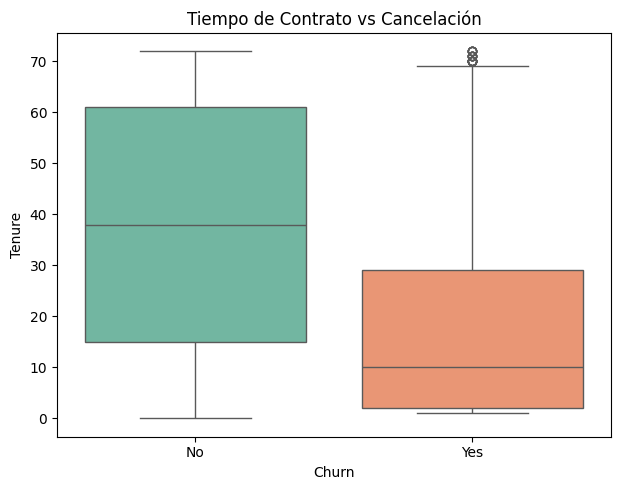

In [47]:
print("Análisis Dirigido: Variables vs Cancelación")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='Churn', y='Tenure', data=datos, palette='Set2')
plt.title('Tiempo de Contrato vs Cancelación')

plt.tight_layout()
plt.show()

##Corrección de flujo

In [49]:
if 'Churn_Yes' in datos_modelo.columns:
    datos_modelo = datos_modelo.rename(columns={'Churn_Yes': 'Churn'})
elif 'Churn' in datos_modelo.columns and datos_modelo['Churn'].dtype == 'O':
    datos_modelo['Churn'] = datos_modelo['Churn'].map({'Yes': 1, 'No': 0})

datos_modelo = datos_modelo.dropna()

X = datos_modelo.drop(columns=['Churn'])
y = datos_modelo['Churn']

##SEPARACIÓN DE DATOS

In [52]:
# Dividimos 70% entrenamiento y 30% prueba.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"Datos separados: Entrenamiento {X_train.shape[0]} filas | Prueba {X_test.shape[0]} filas")

Datos separados: Entrenamiento 4930 filas | Prueba 2113 filas


##NORMALIZACIÓN / ESTANDARIZACIÓN

In [53]:
# Estandarizamos solo las variables numéricas originales para no afectar las binarias
num_cols = datos.select_dtypes(include=["int64", "float64"]).columns
# Filtramos las que siguen existiendo en X
num_cols = [col for col in num_cols if col in X_train.columns]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

if num_cols:
    X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])
    print(f"Variables estandarizadas: {num_cols}")

Variables estandarizadas: ['Tenure', 'ChargesMonthly']


##CREACIÓN DE MODELOS

In [54]:
print("Entrenando Modelos...")

# Modelo A: Regresión Logística
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

print("\n--- Resultados Regresión Logística ---")
print(f"Precisión (Accuracy): {accuracy_score(y_test, y_pred_log):.4f}")
print(classification_report(y_test, y_pred_log))

# Modelo B: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\n--- Resultados Random Forest ---")
print(f"Precisión (Accuracy): {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

Entrenando Modelos...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



--- Resultados Regresión Logística ---
Precisión (Accuracy): 0.7974
              precision    recall  f1-score   support

       False       0.84      0.89      0.87      1552
        True       0.64      0.55      0.59       561

    accuracy                           0.80      2113
   macro avg       0.74      0.72      0.73      2113
weighted avg       0.79      0.80      0.79      2113


--- Resultados Random Forest ---
Precisión (Accuracy): 0.7856
              precision    recall  f1-score   support

       False       0.83      0.89      0.86      1552
        True       0.62      0.50      0.55       561

    accuracy                           0.79      2113
   macro avg       0.73      0.69      0.71      2113
weighted avg       0.77      0.79      0.78      2113



# Evaluación de los Modelos


Evaluación: Regresión Logística
Exactitud (Train) : 0.8103
Exactitud (Test)  : 0.7974
Precisión         : 0.6383
Recall            : 0.5472
F1-score          : 0.5893


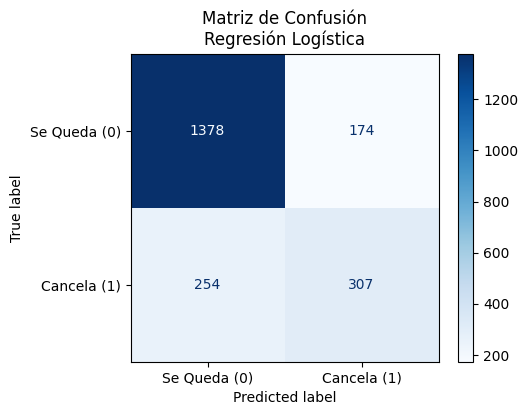


Evaluación: Random Forest
Exactitud (Train) : 0.9978
Exactitud (Test)  : 0.7856
Precisión         : 0.6195
Recall            : 0.4991
F1-score          : 0.5528


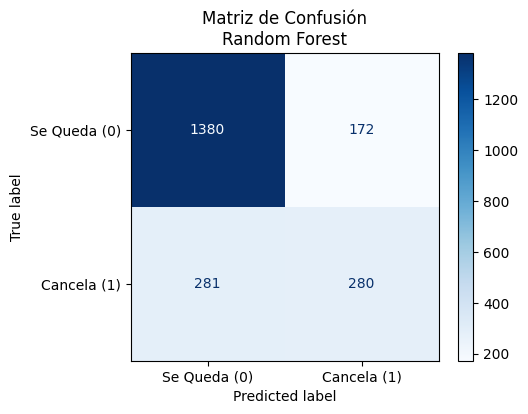

In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluar_modelo(modelo, X_train, y_train, X_test, y_test, nombre_modelo):
    y_pred_test = modelo.predict(X_test)
    y_pred_train = modelo.predict(X_train)

    acc_test = accuracy_score(y_test, y_pred_test)
    prec = precision_score(y_test, y_pred_test)
    rec = recall_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)
    acc_train = accuracy_score(y_train, y_pred_train)

    print(f"\nEvaluación: {nombre_modelo}")
    print(f"Exactitud (Train) : {acc_train:.4f}")
    print(f"Exactitud (Test)  : {acc_test:.4f}")
    print(f"Precisión         : {prec:.4f}")
    print(f"Recall            : {rec:.4f}")
    print(f"F1-score          : {f1:.4f}")

    cm = confusion_matrix(y_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Se Queda (0)', 'Cancela (1)'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(cmap='Blues', values_format='d', ax=ax)
    plt.title(f'Matriz de Confusión\n{nombre_modelo}')
    plt.show()

evaluar_modelo(log_reg, X_train_scaled, y_train, X_test_scaled, y_test, "Regresión Logística")
evaluar_modelo(rf_model, X_train, y_train, X_test, y_test, "Random Forest")

##Ajustes

Entrenando Modelos Ajustados...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Evaluación: Regresión Logística (Ajustada)
Exactitud (Train) : 0.7554
Exactitud (Test)  : 0.7345
Precisión         : 0.5000
Recall            : 0.7986
F1-score          : 0.6150


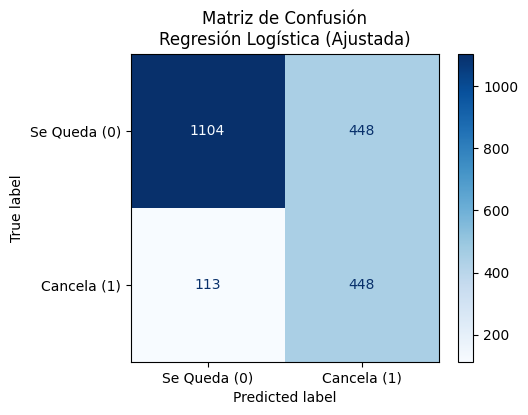


Evaluación: Random Forest (Ajustado)
Exactitud (Train) : 0.7755
Exactitud (Test)  : 0.7478
Precisión         : 0.5165
Recall            : 0.7807
F1-score          : 0.6217


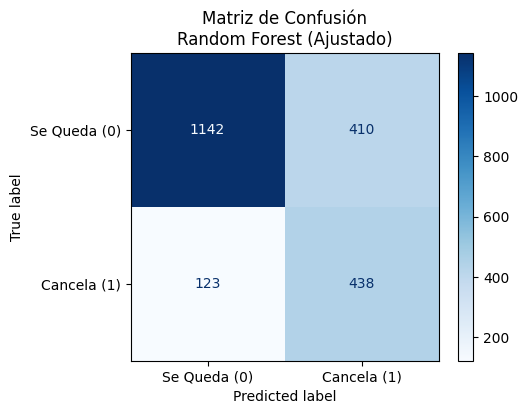

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

print("Entrenando Modelos Ajustados...")

# 1. Regresión Logística Balanceada
log_reg_ajustada = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

# Entrenamos con los datos estandarizados
log_reg_ajustada.fit(X_train_scaled, y_train)

# 2. Random Forest Balanceado
rf_ajustado = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    max_depth=6,
    min_samples_leaf=5
)

# Entrenamos Random Forest
rf_ajustado.fit(X_train, y_train)

# 3. Evaluación de los Nuevos Modelos
evaluar_modelo(log_reg_ajustada, X_train_scaled, y_train, X_test_scaled, y_test, "Regresión Logística (Ajustada)")
evaluar_modelo(rf_ajustado, X_train, y_train, X_test, y_test, "Random Forest (Ajustado)")

##REGRESION LOGISTICA


📌 Analizando los motivos de cancelación según Regresión Logística...


/tmp/ipython-input-283/4084646456.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variable', data=datos_coef, palette=colores)


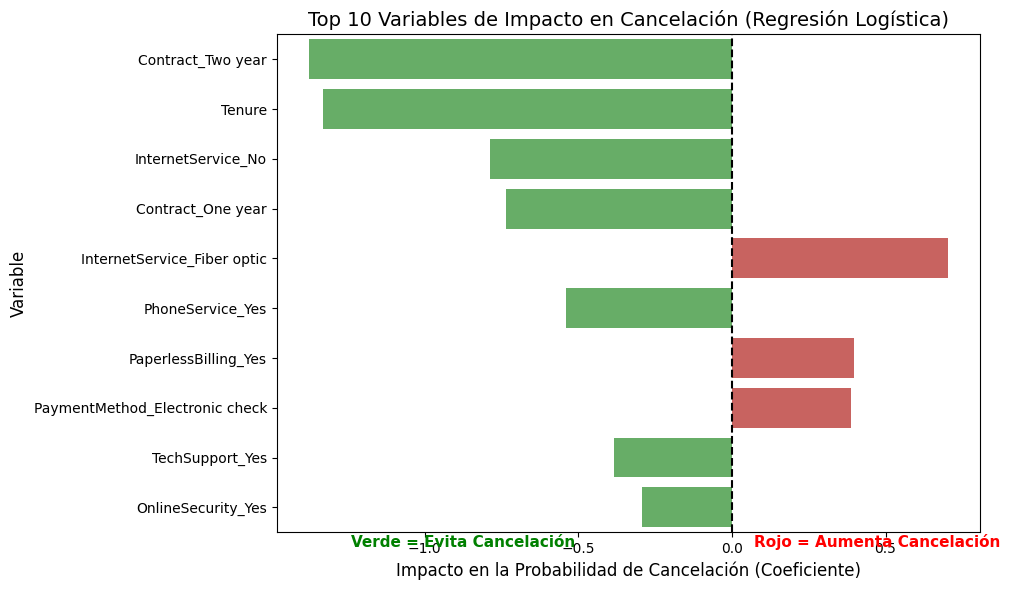

In [57]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extraer los coeficientes de la Regresión Logística
coeficientes = log_reg_ajustada.coef_[0]
nombres_variables = X_train.columns

# 2. Crear un DataFrame con los coeficientes
datos_coef = pd.DataFrame({
    'Variable': nombres_variables,
    'Coeficiente': coeficientes,
    'Importancia_Absoluta': np.abs(coeficientes)
})

# Ordenar de mayor a menor impacto absoluto y tomar el Top 10
datos_coef = datos_coef.sort_values(by='Importancia_Absoluta', ascending=False).head(10)

# 3. Graficar
print("\n📌 Analizando los motivos de cancelación según Regresión Logística...")
plt.figure(figsize=(10, 6))

# Crear una lista de colores: Rojo si empuja a cancelar (> 0), Verde si retiene al cliente (< 0)
colores = ['#d9534f' if coef > 0 else '#5cb85c' for coef in datos_coef['Coeficiente']]

# Gráfico de barras
sns.barplot(x='Coeficiente', y='Variable', data=datos_coef, palette=colores)

plt.title('Top 10 Variables de Impacto en Cancelación (Regresión Logística)', fontsize=14)
plt.xlabel('Impacto en la Probabilidad de Cancelación (Coeficiente)', fontsize=12)
plt.ylabel('Variable', fontsize=12)

# Línea central en el cero
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)

# Textos explicativos en el gráfico
plt.text(datos_coef['Coeficiente'].max() * 0.1, len(datos_coef)-0.2, 'Rojo = Aumenta Cancelación', color='red', fontsize=11, fontweight='bold')
plt.text(datos_coef['Coeficiente'].min() * 0.9, len(datos_coef)-0.2, 'Verde = Evita Cancelación', color='green', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

#RANDOM FOREST

Analizando los motivos de cancelación...


/tmp/ipython-input-283/3730783326.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=datos_importancias, palette='magma')


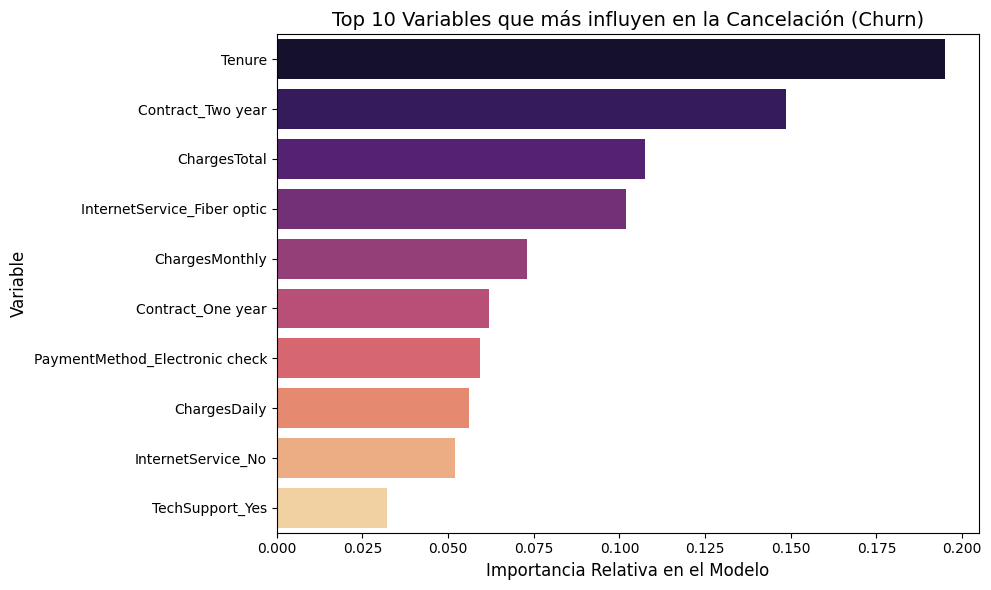

In [58]:
# 1. Extraer las importancias del Random Forest ajustado
importancias = rf_ajustado.feature_importances_
nombres_variables = X_train.columns

# 2. Crear un DataFrame para ordenarlas
datos_importancias = pd.DataFrame({
    'Variable': nombres_variables,
    'Importancia': importancias
})

# Ordenar de mayor a menor y tomar el Top 10
datos_importancias = datos_importancias.sort_values(by='Importancia', ascending=False).head(10)

# 3. Grafica
print("Analizando los motivos de cancelación...")
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=datos_importancias, palette='magma')
plt.title('Top 10 Variables que más influyen en la Cancelación (Churn)', fontsize=14)
plt.xlabel('Importancia Relativa en el Modelo', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.tight_layout()
plt.show()

#CONCLUSION



# Modelos Predictivos

Se usaron los modelos de Regresión Logísca y Random Forest.
 Ambos modelos son capaces de detectar a prácticamente el 80% de los clientes en riesgo de cancelación (Recall: 79.8% para Regresión Logística y 78.0% para Random Forest), brindando a Telecom X un margen de maniobra crucial para retenerlos.

# ¿Por qué se van los clientes?

## Factores de Riesgo (Impulsan la Cancelación)
Estas variables mostraron un impacto positivo en la Regresión Logística (barras rojas) y alta importancia en el Random Forest, lo que significa que aumentan significativamente la probabilidad de que un cliente se vaya:

1. Internet de Fibra Óptica (InternetService_Fiber optic): Es el servicio que más empuja a los clientes a cancelar. Esto es una alerta crítica pues un servicio que debería ser premium está generando insatisfacción.

2. Método de Pago por Cheque Electrónico (PaymentMethod_Electronic check): Los clientes que usan este método tienen una tasa de cancelación inusualmente alta. Puede indicar fricción en el proceso de pago o estar correlacionado con un perfil demográfico específico.

3. Cargos Acumulados y Mensuales (ChargesTotal, ChargesMonthly): Como revela el Random Forest, el monto que paga el cliente es de los 5 factores más importantes. Existe una clara sensibilidad al precio.

4. Facturación sin papel (PaperlessBilling_Yes): Los clientes con facturación digital muestran mayor propensión a la cancelación, posiblemente porque les es más fácil ignorar los correos hasta que deciden cortar el servicio, o porque carecen del recordatorio físico del valor del servicio.

# Factores de Protección (Impulsan la Lealtad)
Estas variables mostraron coeficientes negativos fuertes (barras verdes), lo que significa que actúan como un ancla para retener al cliente:

1. Contratos a Largo Plazo (Contract_Two year, Contract_One year): Son, por mucho, la mejor herramienta de retención. El contrato a dos años es la variable que más fuertemente evita la cancelación según la Regresión Logística.

2. Antigüedad del Cliente (Tenure): Es la variable #1 en importancia general (Random Forest). A medida que el cliente pasa los primeros meses críticos, su probabilidad de irse cae drásticamente.

3. Servicios de Soporte y Seguridad (TechSupport_Yes, OnlineSecurity_Yes): Tener contratado el soporte técnico y la seguridad en línea reduce la probabilidad de cancelación, ya que mejoran la experiencia del usuario ante problemas técnicos.

#Estrategias de Retención Propuestas

Basados en la evidencia de los datos, sugerimos a Telecom X las siguientes acciones:

1. Auditoría Urgente al Servicio de Fibra Óptica:
Investigar de inmediato por qué los usuarios de fibra óptica están cancelando. Se debe revisar si hay problemas de latencia, caídas constantes del servicio o si el precio está muy por encima de los competidores locales.

2. Campaña de Migración de Contratos:
Identificar a los clientes que pagan mes a mes (sin contrato) y ofrecerles un descuento sustancial en su mensualidad o la inclusión de "Tech Support" gratuito si deciden firmar un contrato de 1 o 2 años. Los datos demuestran que el contrato a dos años es el blindaje más fuerte contra el churn.

3. Revisión de la Experiencia de Pago (Cheque Electrónico):
Auditar la pasarela de pago para aquellos que usan Electronic Check. Si hay fallos, cargos dobles o dificultad en la interfaz, esto debe corregirse. Alternativamente, incentivar a estos usuarios a cambiar su método de pago a tarjeta de crédito automatizada.

4. Onboarding y Blindaje en Primeros Meses:
Dado que la variable Tenure (Antigüedad) es crucial, los primeros meses son los de mayor riesgo. Implementar llamadas de cortesía y tutoriales de servicio en los primeros 90 días ayudará a construir la lealtad necesaria para que el cliente madure en la plataforma.